In [1]:
from temgym_core.gaussian import Detector, RandomPhaseSample, square_input_wave, run_to_end_vmapped
from temgym_core.evaluate import evaluate_gaussians_gpu_kernel_wrapper
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt

jax.config.update("jax_enable_x64", True)
%matplotlib widget

In [2]:
def add_poisson_noise(key, image, max_counts=1e4, eps=1e-12, read_noise_sigma=0.0):
    """
    Add Poisson shot noise to an image.

    Parameters
    ----------
    key : jax.random.PRNGKey
        Random key for JAX.
    image : array
        Noiseless intensity image, >= 0. Can be arbitrary units.
    max_counts : float
        Expected counts at the maximum intensity pixel.
    eps : float
        Numerical epsilon for stability.

    Returns
    -------
    noisy_image : array
        Image with Poisson noise, rescaled back to match original intensity scale.
    """
    # Ensure non-negative
    image = jnp.clip(image, 0.0)

    # Map intensities to expected counts (lambda)
    im_max = jnp.max(image)
    scale = max_counts / (im_max + eps)
    lam = image * scale  # expected counts per pixel

    # Sample Poisson counts
    counts = jax.random.poisson(key, lam=lam)

    key, subkey = jax.random.split(key)
    counts = counts + jax.random.normal(subkey, counts.shape) * read_noise_sigma

    # Map back to original scale
    noisy_image = counts / scale



    return noisy_image


In [3]:
width=100e-9
height=100e-9
x0, y0=0, 0
z0=0.0
theta=0.0
strength=1e-12
correlation_length=1e-11
edge_sharpness=5e6
n_px=1024

rays_in = square_input_wave(aperture_length=140e-9,
                            waist=5e-10,
                            voltage=100e3)

k = rays_in.k[0]
wavelength = rays_in.wavelength[0]

random_sample = RandomPhaseSample(
    strength=strength,
    width=width,
    height=height,
    x0=x0,
    y0=y0,
    z=0.0,
    theta=theta,
    correlation_length=correlation_length,
    edge_sharpness=edge_sharpness,
)

detector = Detector(
    z=5e-5,
    pixel_size=(width / n_px, height / n_px),
    shape=(n_px, n_px),
)

xy=detector.coords
phase_in = jax.vmap(random_sample.phase_shift)(xy).reshape((n_px, n_px))

In [4]:
rays_out_after_sample = run_to_end_vmapped(
    rays_in,
    (random_sample,))

rays_out_after_sample_propagated = run_to_end_vmapped(
    rays_out_after_sample,
    (random_sample, detector,),
)

field_in = evaluate_gaussians_gpu_kernel_wrapper(
    rays_in,
    detector,
)

field_out_after_sample = evaluate_gaussians_gpu_kernel_wrapper(
    rays_out_after_sample,
    detector,
)

field_out_after_sample_propagated = evaluate_gaussians_gpu_kernel_wrapper(
    rays_out_after_sample_propagated,
    detector,
)

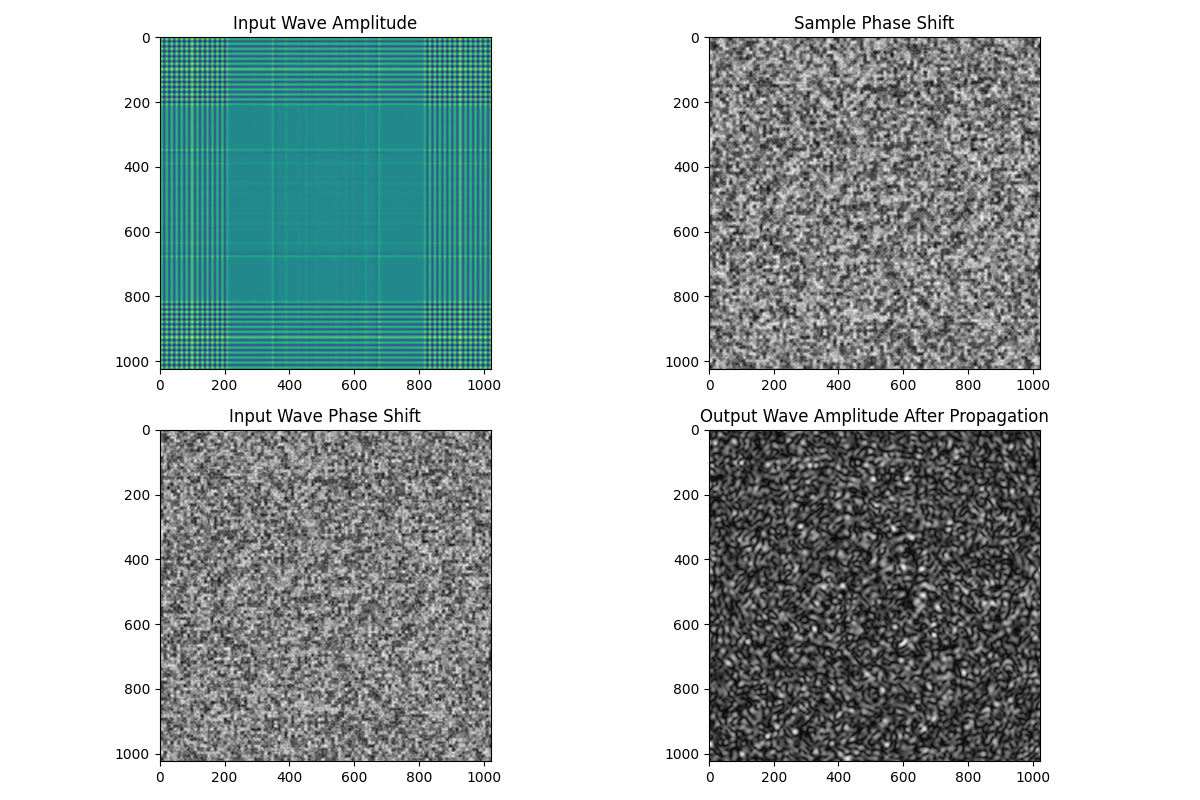

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0, 0].imshow(jnp.abs(field_in))
axes[0, 0].set_title("Input Wave Amplitude")

axes[0, 1].imshow(phase_in, cmap="gray")
axes[0, 1].set_title("Sample Phase Shift")

axes[1, 0].imshow(jnp.angle(field_out_after_sample), cmap="gray")
axes[1, 0].set_title("Input Wave Phase Shift")

axes[1, 1].imshow(jnp.abs(field_out_after_sample_propagated), cmap="gray")
axes[1, 1].set_title("Output Wave Amplitude After Propagation")

plt.tight_layout()

Text(0.5, 1.0, 'Noisy Intensity Image After Propagation')

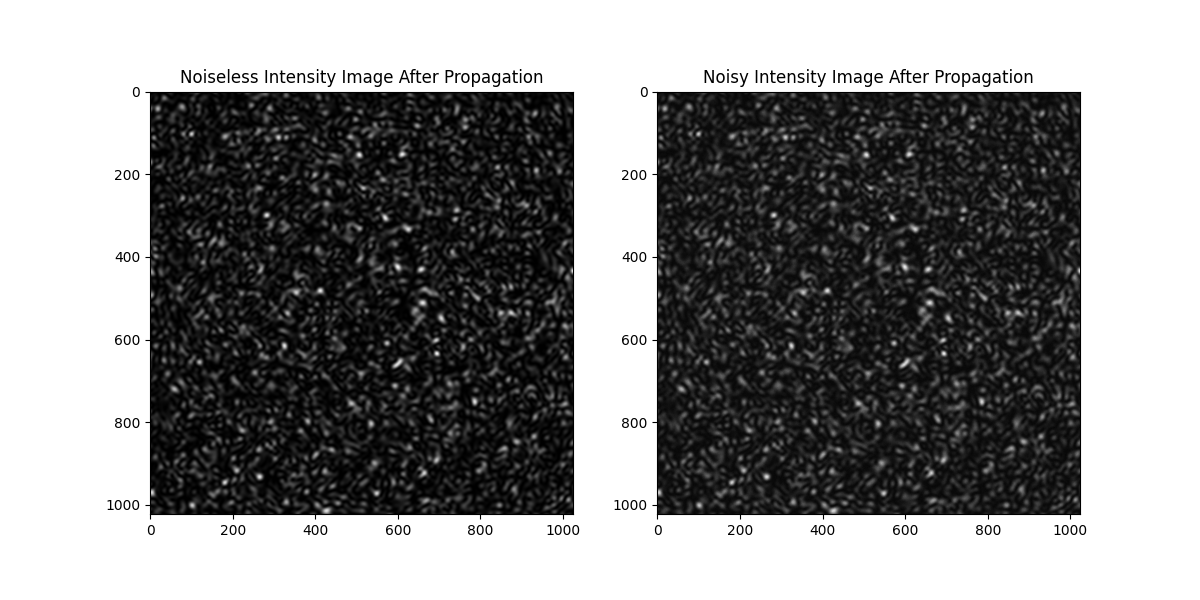

In [6]:
noisy_image = add_poisson_noise(jax.random.PRNGKey(0), jnp.abs(field_out_after_sample_propagated) ** 2, max_counts=1000.0, read_noise_sigma=10.0)

fig, axs = plt.subplots(1, 2, figsize=(12, 6))
axs[0].imshow(jnp.abs(field_out_after_sample_propagated) ** 2, cmap="gray")
axs[0].set_title("Noiseless Intensity Image After Propagation")
axs[1].imshow(noisy_image, cmap="gray")
axs[1].set_title("Noisy Intensity Image After Propagation")

Text(0.5, 1.0, 'FFT of Noisy Intensity Image')

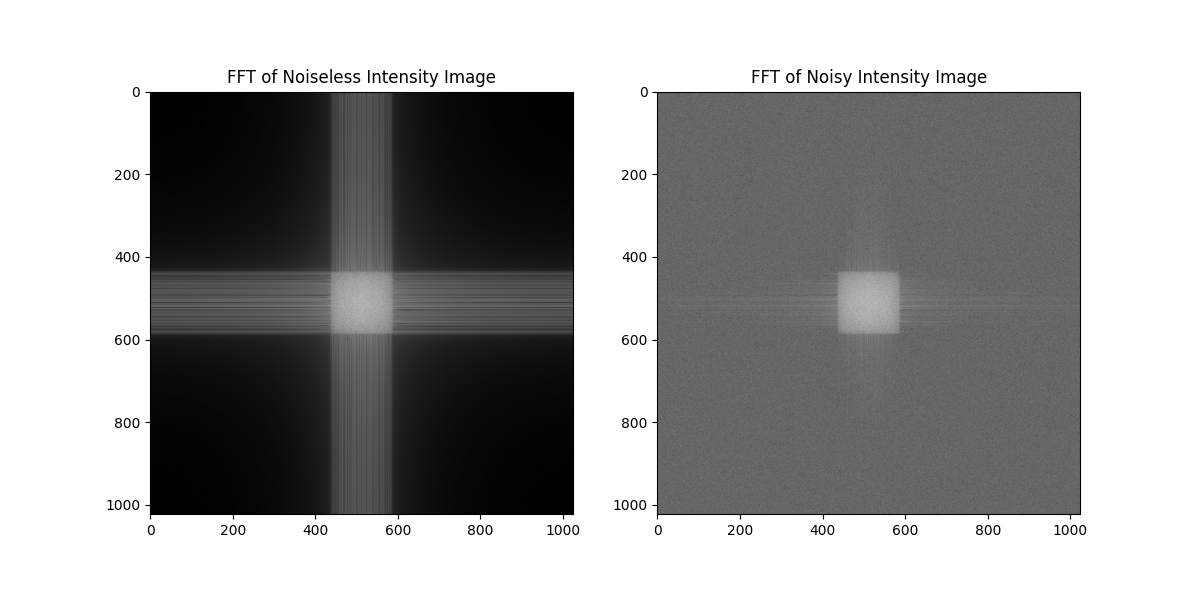

In [7]:
fft_of_image = jnp.fft.fftshift(jnp.fft.fft2(jnp.abs(field_out_after_sample_propagated) ** 2))
fft_of_noisy_image = jnp.fft.fftshift(jnp.fft.fft2(noisy_image))

fig, axs = plt.subplots(1, 2, figsize=(12, 6))
axs[0].imshow(jnp.log10(jnp.abs(fft_of_image)), cmap="gray")
axs[0].set_title("FFT of Noiseless Intensity Image")
axs[1].imshow(jnp.log10(jnp.abs(fft_of_noisy_image)), cmap="gray")
axs[1].set_title("FFT of Noisy Intensity Image")